Question 05

Part a)

In [1]:
import numpy as np

def gaussian_kernel(size, sigma):
    k = size // 2
    x, y = np.mgrid[-k:k+1, -k:k+1]
    
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    
    # Normalize
    kernel = kernel / np.sum(kernel)
    
    return kernel

kernel_5x5 = gaussian_kernel(5, 2)
print(kernel_5x5)

[[0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.03832756 0.05576627 0.06319146 0.05576627 0.03832756]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]]


Part b)

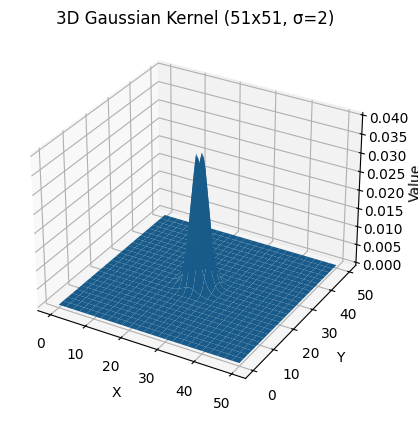

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

kernel_51 = gaussian_kernel(51, 2)

x = np.arange(51)
y = np.arange(51)
X, Y = np.meshgrid(x, y)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, kernel_51)

ax.set_title("3D Gaussian Kernel (51x51, σ=2)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Value")

plt.show()

Part c)

In [4]:
import cv2

def apply_convolution(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    
    pad_h = kh // 2
    pad_w = kw // 2
    
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    
    output = np.zeros_like(image)
    
    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)
    
    return output

# Load grayscale image
img = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

# Apply smoothing
smoothed_manual = apply_convolution(img, kernel_5x5)

# Show results inline (IMPORTANT for your assignment)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title("Manual Gaussian")
plt.imshow(smoothed_manual, cmap='gray')

plt.show()

AttributeError: 'NoneType' object has no attribute 'shape'